# **Modelação e Análise de Circuitos com Falhas via SMT**
### *Trabalho Prático 2 - Grupo 16*

Este trabalho teve como objetivo a modelação e análise de um circuito booleano polinomial de 2º grau utilizando ferramentas SMT.

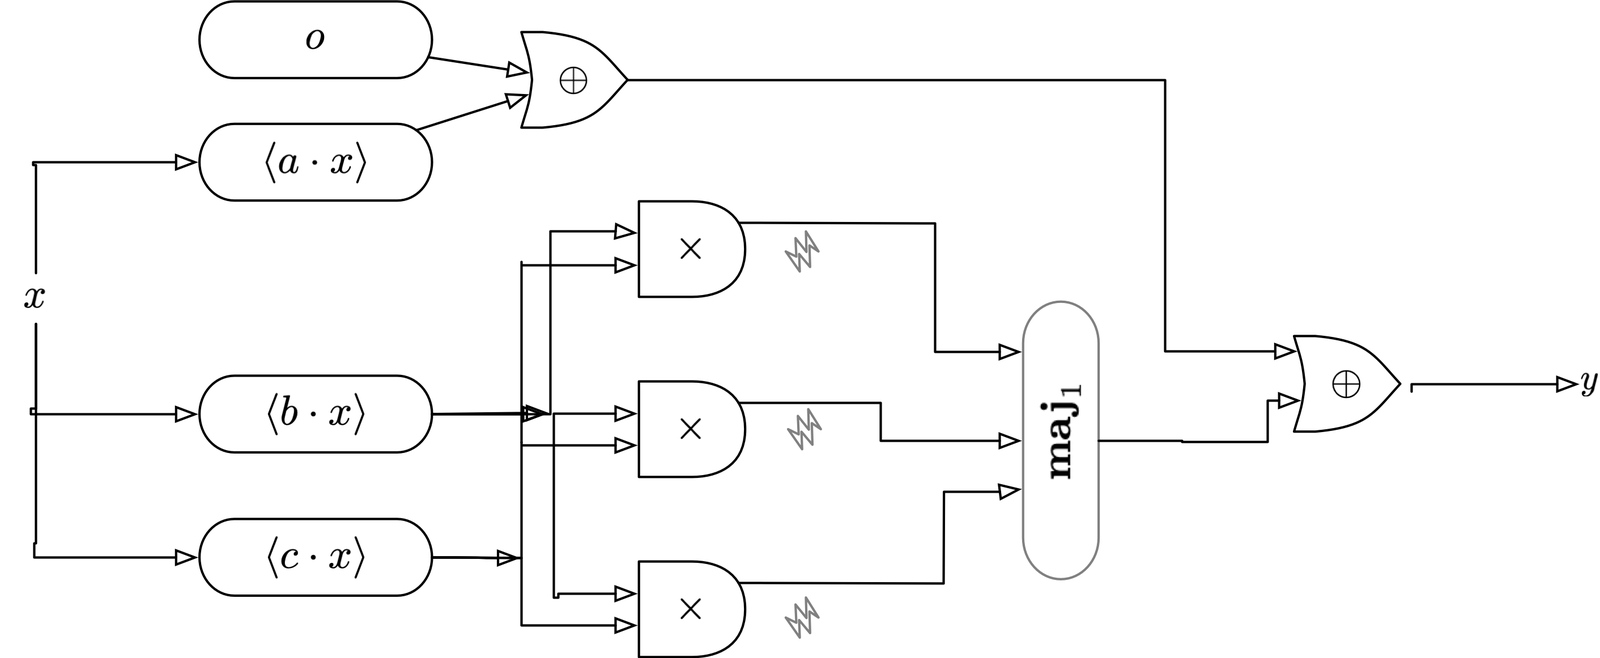

O circuito em questão, protegido por um sistema de redundância tripla e portas de maioria (`maj`), foi analisado em duas frentes: a sua vulnerabilidade a ataques de falha coordenados e a sua robustez geral contra falhas.

Optamos por usar pySMT (com o solver Z3) para criar um modelo matemático preciso do circuito e das suas potenciais falhas, conforme descrito no enunciado.

## Metodologia

Para a realização deste problema optamos por dividir-lo nas três tarefas sugeridas no enunciado.
1. Construção dos parâmetros do circuito.
2. Encontrar um 'Segredo Falso' (z')
3. Maximizar Falhas

## **Tarefa 1 - Construir o Circuito**

Para construir o circuito, foi necessário primeiro modelar o seu comportamento. O sistema é composto por n sub-circuitos, cada um descrito por um polinómio booleano de 2º grau. A fórmula geral para um sub-circuito é:$$f(p;x) \equiv o \oplus \langle a \cdot x \rangle \oplus (\langle b \cdot x \rangle \times \langle c \cdot x \rangle)$$...em que $p=(o,a,b,c)$ são os parâmetros do circuito.

Para implementar esta fórmula, começámos por definir a sua componente base, a expressão linear $\langle a \cdot x \rangle$. Conforme a definição, esta expressão é um XOR de todos os inputs $x_i$ cuja "máscara" $a_i$ correspondente seja 1:
$$\langle a \cdot x \rangle \equiv \sum_{i=1}^{n}a_{i}x_{i} \equiv \bigoplus_{a_{i}=1}x_{i}$$
Isto foi implementado em Python através da seguinte função auxiliar:

In [2]:
def termo_linear(a, x):
    """ Calcula <a.x> = (a_1 AND x_1) XOR (a_2 AND x_2) ... XOR (a_n AND x_n) """
    # (a & x) faz o AND elemento-a-elemento
    # .sum() conta quantos 'True' resultaram
    # % 2 faz o XOR de tudo (se a soma for ímpar -> 1, se for par -> 0)
    return (a & x).sum() % 2

Com esta função, e usando os operadores `^` (XOR) e `&` (AND) do Python, foi possível definir a função do polinómio sem falhas. Esta função é crucial, pois é usada para gerar os parâmetros do circuito.

In [3]:
def f_sem_falhas(p, x):
    """ Calcula f(p;x) = o ^ <a.x> ^ (<b.x> AND <c.x>) """
    o, a, b, c = p
    
    termo_a = termo_linear(a, x)
    termo_b = termo_linear(b, x)
    termo_c = termo_linear(c, x)
    
    # O operador ^ é o XOR em Python
    # O operador & é o AND em Python (para 0s e 1s)
    resultado = o ^ termo_a ^ (termo_b & termo_c)
    return resultado


Falta-nos agora a dita construção do circuito com base no segredo `z` e na "master seed" `s`. Este processo algorítmico foi o seguinte:

1. A "master seed" `s` é usada para inicializar um Gerador de Números Pseudo-Aleatórios (PRNG)

2. Este PRNG gera `n` "sub-seeds" (`s_1`, ..., `s_n`), uma para cada sub-circuito

3. Para cada sub-circuito `i`, a sua "sub-seed" `s_i` é usada para gerar os vetores de parâmetros `a_i`, `b_i`, e `c_i`

4. O parâmetro offset `o_i` é calculado usando a função que acabámos de definir: 
$o_i \leftarrow f(p_0; z)$ , 
onde $p_0 = (0, a_i, b_i, c_i)$. 

Isto "incorpora" o segredo `z` nos parâmetros públicos, garantindo que `z` é uma raíz do polinómio sem falhas. Esta lógica foi implementada na função gerar_parametros_circuito:

In [4]:
import numpy as np
def gerar_parametros_circuito(z_bits, s_master, n, k=32):
    """
    Gera os parâmetros (o_i, a_i, b_i, c_i) para os n sub-circuitos.
    Assume que z_bits é um array numpy booleano de comprimento n.
    K é o parâmetro de segurança
    """
    
    # 1. Inicializar o PRNG "Master" com a 's_master'
    rng_master = np.random.default_rng(seed=s_master)

    # 2. Gerar as n 'sub-seeds'
    sub_seeds = rng_master.integers(low=0, high=2**k, size=n)

    parametros_todos = []
    print(f"A gerar {n} sub-circuitos...")

    for i in range(n):
        # 3. Gerar a_i, b_i, c_i com a 'sub_seed' s_i
        rng_sub = np.random.default_rng(seed=sub_seeds[i])
        a_i = rng_sub.integers(0, 2, size=n, dtype=bool)
        b_i = rng_sub.integers(0, 2, size=n, dtype=bool)
        c_i = rng_sub.integers(0, 2, size=n, dtype=bool)

        # 4. Calcular o offset o_i
        p0 = (0, a_i, b_i, c_i)
        o_i = f_sem_falhas(p0, z_bits) # Usa z_bits diretamente
        
        # 5. Guardar os parâmetros finais
        p_final = (o_i, a_i, b_i, c_i)
        parametros_todos.append(p_final)

    print("Parâmetros do circuito gerados com sucesso.")
    return parametros_todos

In [5]:
from pysmt.shortcuts import (
    Solver, Symbol, BOOL, INT, 
    And, Or, Not, Ite, Iff, Xor, Plus, Int, Bool, FALSE, GT
)
from pysmt.typing import BOOL

def construir_modelo_smt(parametros_todos, n):
    """
    Constrói o modelo SMT para o circuito n x n com falhas.
    """
    
    # --- 1. Definir Variáveis SMT Principais ---
    
    # x = Vetor de input de n bits
    x = [Symbol(f"x_{i}", BOOL) for i in range(n)]
    
    # y = Vetor de output de n bits
    y = [Symbol(f"y_{i}", BOOL) for i in range(n)]
    
    # --- 2. Definir Variáveis SMT de Falha ---
    # 3 falhas por 'and', n sub-circuitos
    # falhas[i][j] = falha do sub-circuito i, porta 'and' j (j=0,1,2)
    falhas = [
        [Symbol(f"falha_{i}_{j}", BOOL) for j in range(3)] 
        for i in range(n)
    ]
    
    lista_de_formulas = [] # Guarda a fórmula para cada y_i

    # --- 3. Construir a Lógica para cada Sub-circuito ---
    for i in range(n):
        o_i, a_i, b_i, c_i = parametros_todos[i]
        
        # Converte os parâmetros numpy (True/False) para SMT (TRUE(), FALSE())
        o_i_smt = Bool(bool(o_i))

        # --- Lógica do Sub-circuito i ---
        
        # a. Termos Lineares (Grandes XORs)
        def multi_xor(terms):
            if not terms:
                return FALSE()
            expr = terms[0]
            for t in terms[1:]:
                expr = Xor(expr, t)
            return expr
        # <a.x> = Xor( ... x_k ... ) para todo k onde a_i_smt[k] é TRUE
        termo_a = multi_xor([x[k] for k in range(n) if a_i[k]])
        termo_b = multi_xor([x[k] for k in range(n) if b_i[k]])
        termo_c = multi_xor([x[k] for k in range(n) if c_i[k]])

        # b. As 3 Portas 'and' (com redundância) [cite: 25, 64]
        and_ideal = And(termo_b, termo_c) # O resultado que devia dar

        # c. Aplicar as falhas
        # Se falha=True, inverte o resultado
        out_and = []
        for j in range(3):
            falha_ij = falhas[i][j]
            # Ite(cond, se_verdadeiro, se_falso)
            out_and_j = Ite(falha_ij, Not(and_ideal), and_ideal)
            out_and.append(out_and_j)
            
        # d. Porta de Maioria (maj_1) [cite: 25]
        # Maj(a,b,c) = (a&b) | (a&c) | (b&c)
        maj_out = Or(
            And(out_and[0], out_and[1]),
            And(out_and[0], out_and[2]),
            And(out_and[1], out_and[2])
        )
        
        # e. Fórmula final para y_i
        # y_i = o_i ^ <a.x> ^ maj_out [cite: 12, 25]
        formula_yi = Iff(y[i], multi_xor([o_i_smt, termo_a, maj_out]))
        lista_de_formulas.append(formula_yi)

    # A fórmula total é o AND de todas as fórmulas de sub-circuito
    formula_final = And(lista_de_formulas)
    
    print("Modelo SMT construído com sucesso.")
    
    # Devolvemos as "pontas" do modelo
    return x, y, falhas, formula_final


## **Tarefa 2 - Encontrar uma Vulnerabilidade (O "Ataque")**

Após a construção do modelo SMT na Tarefa 1, o objetivo da Tarefa 2 foi utilizar este modelo para testar a segurança do circuito.

A análise consistiu em simular um ataque de falha, onde um atacante tenta encontrar um "segredo falso" (`z'`) que, combinado com um conjunto de falhas no circuito, engana o sistema fazendo-o produzir o output de sucesso $0^n$.

Para realizar este teste, foi usado um `Solver` SMT (`Z3`) ao qual foram adicionadas as seguintes restrições:

1. Lógica do Circuito: A `formula_final` (gerada na Tarefa 1) foi adicionada como a restrição base, garantindo que a física do circuito (incluindo a lógica de falhas) fosse obedecida.

2. Restrição de Output: O output do circuito (`y`) foi forçado a ser o vetor nulo (y = $0^n$), simulando um resultado "correto" ou de "sucesso".

3. Restrição de Input (`z' != z`): Foi adicionada uma restrição que proíbe o input (`x`) de ser igual ao segredo real (`z`). Isto força o solver a procurar um "segredo falso" (`z'`).

4. Restrição de Falhas: Foi imposto que o número de falhas ativas fosse "não nulo", ou seja, pelo menos uma das variáveis `falha_i_j` tinha de ser True.


A função ``encontrar_segredo_falso`` implementou esta lógica:

In [6]:
def encontrar_segredo_falso(n, x, y, falhas, formula_final, z_bits_reais):
    """
    Tenta encontrar um z' != z e um conjunto de falhas > 0
    tal que o output do circuito y seja 0^n.
    """
    
    with Solver(name="z3") as s:
        
        # --- Adicionar Restrições ---
        
        # Restrição D: A lógica do circuito tem de ser obedecida
        s.add_assertion(formula_final)
        
        # Restrição A: O output 'y' tem de ser 0^n (tudo False)
        target_output = And([Not(y[i]) for i in range(n)])
        s.add_assertion(target_output)
        
        # Restrição B: O input 'x' NÃO pode ser o segredo real 'z'
        z_real_smt = [Bool(bool(b)) for b in z_bits_reais]
        x_equals_z_real = And([Iff(x[i], z_real_smt[i]) for i in range(n)])
        s.add_assertion(Not(x_equals_z_real))
        
        # Restrição C: Pelo menos UMA falha tem de estar ativa
        todas_as_falhas = [falha_bit for sublist in falhas for falha_bit in sublist]
        pelo_menos_uma_falha = Or(todas_as_falhas)
        s.add_assertion(pelo_menos_uma_falha)

        # --- Verificar o Modelo ---
        
        print("\nA procurar um 'segredo falso' (z') com falhas...")
        if s.solve():
            print("--- SUCESSO! Encontrado z' e falhas ---")
            model = s.get_model()
            
            # 1. Obter o z' (que é o valor do input 'x')
            z_prime_vals = [model.get_py_value(x[i]) for i in range(n)]
            print(f"Segredo Falso (z'): {z_prime_vals}")
            
            # 2. Obter as falhas ativas
            falhas_ativas = []
            for i in range(n):
                for j in range(3):
                    if model.get_py_value(falhas[i][j]) == True:
                        falhas_ativas.append(f"falha_{i}_{j}")
            print(f"Falhas Ativas: {falhas_ativas}")
            
        else:
            print("--- FALHA (UNSAT) ---")
            print("Não foi possível encontrar um z' que satisfaça as condições.")

### Teste simples: Resultado e Análise

In [7]:
N = 4
S_MASTER = 12345

z_bits_reais = np.array([True, False, False, True])

parametros = gerar_parametros_circuito(z_bits_reais, S_MASTER, N)

x_smt, y_smt, falhas_smt, formula_smt = construir_modelo_smt(parametros, N)

encontrar_segredo_falso(N, x_smt, y_smt, falhas_smt, formula_smt, z_bits_reais)

A gerar 4 sub-circuitos...
Parâmetros do circuito gerados com sucesso.
Modelo SMT construído com sucesso.

A procurar um 'segredo falso' (z') com falhas...
--- SUCESSO! Encontrado z' e falhas ---
Segredo Falso (z'): [False, False, False, True]
Falhas Ativas: ['falha_0_0', 'falha_0_1', 'falha_0_2', 'falha_1_0', 'falha_1_1', 'falha_1_2']


O resultado demonstra que o circuito é vulnerável a um ataque de falha. O *solver* conseguiu encontrar uma solução que satisfaz todas as condições:
- Descobriu um Segredo Falso (z') ([False, False, False, True]) que é diferente do segredo real ([True, False, False, True]).

- Identificou um conjunto de 6 falhas ativas que, ao ocorrerem simultaneamente, fazem com que o z' produza o output $0^n$.


Conclui-se que, embora o circuito seja matematicamente seguro num cenário ideal, a sua implementação física com portas ``and`` suscetíveis a falhas abre um vetor de ataque que pode ser explorado, como provado por esta simulação SMT.

## **Tarefa 3 - Análise de Robustez (Maximização de Falhas)**

A terceira e última tarefa mudou o foco da análise: em vez de simular um ataque (como na Tarefa 2), o objetivo foi testar a robustez do circuito e a eficácia do seu design de redundância.

A questão, conforme o enunciado, era "maximizar a probabilidade de falhas and sem que o 'output' $0^n$ seja alterado", assumindo que o input fornecido era o segredo correto z.

Este é um problema de otimização, não de satisfatibilidade. Para o resolver, foi utilizado um Optimizer SMT (`Z3`) em vez de um Solver simples. Ao `optimizer` foram dadas as seguintes restrições e objetivos:

1. Lógica do Circuito: A `formula_final` (gerada na Tarefa 1) foi mantida.

2. Restrição de Input: O *input* `x` foi forçado a ser igual ao segredo real `z`.

3. Restrição de Output: O output `y` foi forçado a manter-se igual a $0^n$, garantindo que o circuito ainda produzia o resultado correto, mesmo sob o efeito das falhas.

4. Objetivo de Maximização: O solver foi instruído a maximizar a soma total de variáveis de falha ativas(`contagem_falhas`).

Esta lógica foi implementada na função `maximizar_falhas`:

In [8]:
def maximizar_falhas(n, x, y, falhas, formula_final, z_bits_reais):
    """
    Maximiza o número de falhas que o circuito aguenta
    enquanto o output (com input z) continua a ser 0^n.
    Implementação por busca iterativa usando Solver (pySMT).
    """
    print("\n--- Tarefa 3: A maximizar falhas (busca iterativa) ---")

    all_faults = [f for sub in falhas for f in sub]
    falhas_int_terms = [Ite(f, Int(1), Int(0)) for f in all_faults]
    contagem_expr = Plus(falhas_int_terms) if falhas_int_terms else Int(0)

    # Construir as restrições fixas (base)
    z_real_smt = [Bool(bool(b)) for b in z_bits_reais]
    restricoes_base = [
        formula_final,
        And([Iff(x[i], z_real_smt[i]) for i in range(n)]),  # x = z real
        And([Not(y[i]) for i in range(n)])                 # y = 0^n
    ]

    with Solver(name="z3") as s:
        for r in restricoes_base:
            s.add_assertion(r)

        best_model = None
        best_count = -1

        # Iterar enquanto houver modelo que melhore o número de falhas
        while s.solve():
            m = s.get_model()
            # contar falhas no modelo actual
            cur_count = sum(1 for f in all_faults if m.get_py_value(f))
            best_count = cur_count
            best_model = m

            # exigir melhoria estrita: contagem > cur_count
            s.add_assertion(GT(contagem_expr, Int(cur_count)))

        if best_model is not None:
            print("--- SUCESSO! Solução de maximização encontrada ---")
            print(f"Número MÁXIMO de falhas que o circuito aguenta: {best_count}")
            falhas_ativas = []
            for idx, f in enumerate(all_faults):
                if best_model.get_py_value(f):
                    i = idx // 3
                    j = idx % 3
                    falhas_ativas.append(f"falha_{i}_{j}")
            print(f"Configuração de falhas que o circuito 'sobreviveu': {falhas_ativas}")
        else:
            print("--- FALHA (UNSAT) ---")
            print("Não foi possível encontrar uma solução (nem mesmo 0 falhas).")

### Teste simples: Resultados e Análise

In [9]:
maximizar_falhas(N, x_smt, y_smt, falhas_smt, formula_smt, z_bits_reais)


--- Tarefa 3: A maximizar falhas (busca iterativa) ---
--- SUCESSO! Solução de maximização encontrada ---
Número MÁXIMO de falhas que o circuito aguenta: 4
Configuração de falhas que o circuito 'sobreviveu': ['falha_0_2', 'falha_1_2', 'falha_2_1', 'falha_3_2']


A análise deste resultado confirma que o design de robustez do circuito funciona exatamente como esperado.

- O circuito é composto por `n=4` sub-circuitos.

- Cada sub-circuito usa redundância tripla (três portas `and`) e uma porta de maioria (`maj`) para agregar os resultados.

- Por definição, uma porta de maioria é desenhada para tolerar uma falha (se duas portas `and` estiverem corretas e uma falhar, a maioria ainda produz o valor correto).

- O *solver* determinou que o número máximo de falhas que o circuito aguenta é 4. A configuração de exemplo mostra que esta solução ótima corresponde a **uma falha em cada um dos 4 sub-circuitos.**

Conclui-se que o mecanismo de defesa é robusto e tolera o número máximo de falhas para o qual foi projetado (1 por sub-circuito), mas falharia se duas falhas ocorressem dentro do mesmo sub-circuito.

In [10]:
#Teste 1
N = 8
S_MASTER = 12345
z_input = np.array([True, False, False, True, True, False, True, False]) # Exemplo p/ 8 bits

parametros = gerar_parametros_circuito(z_input, S_MASTER, N)

x_smt, y_smt, falhas_smt, formula_smt = construir_modelo_smt(parametros, N)

encontrar_segredo_falso(N, x_smt, y_smt, falhas_smt, formula_smt, z_input)

maximizar_falhas(N, x_smt, y_smt, falhas_smt, formula_smt, z_input)

A gerar 8 sub-circuitos...
Parâmetros do circuito gerados com sucesso.
Modelo SMT construído com sucesso.

A procurar um 'segredo falso' (z') com falhas...
--- SUCESSO! Encontrado z' e falhas ---
Segredo Falso (z'): [True, False, True, True, True, False, False, True]
Falhas Ativas: ['falha_0_0', 'falha_0_1', 'falha_1_0', 'falha_1_1', 'falha_1_2', 'falha_5_0', 'falha_5_1', 'falha_5_2']

--- Tarefa 3: A maximizar falhas (busca iterativa) ---
--- SUCESSO! Solução de maximização encontrada ---
Número MÁXIMO de falhas que o circuito aguenta: 8
Configuração de falhas que o circuito 'sobreviveu': ['falha_0_2', 'falha_1_0', 'falha_2_1', 'falha_3_2', 'falha_4_2', 'falha_5_1', 'falha_6_1', 'falha_7_0']


In [11]:
# Teste 2
N = 4
S_MASTER = 12345
z_input = np.array([False, False, False, False]) # Segredo Nulo

parametros = gerar_parametros_circuito(z_input, S_MASTER, N)

x_smt, y_smt, falhas_smt, formula_smt = construir_modelo_smt(parametros, N)

encontrar_segredo_falso(N, x_smt, y_smt, falhas_smt, formula_smt, z_input)

maximizar_falhas(N, x_smt, y_smt, falhas_smt, formula_smt, z_input)

A gerar 4 sub-circuitos...
Parâmetros do circuito gerados com sucesso.
Modelo SMT construído com sucesso.

A procurar um 'segredo falso' (z') com falhas...
--- SUCESSO! Encontrado z' e falhas ---
Segredo Falso (z'): [False, False, True, False]
Falhas Ativas: ['falha_0_0', 'falha_1_0', 'falha_1_1']

--- Tarefa 3: A maximizar falhas (busca iterativa) ---
--- SUCESSO! Solução de maximização encontrada ---
Número MÁXIMO de falhas que o circuito aguenta: 4
Configuração de falhas que o circuito 'sobreviveu': ['falha_0_2', 'falha_1_2', 'falha_2_1', 'falha_3_2']


In [12]:
# Teste 3
N = 4
S_MASTER = 12345
z_input = np.array([True, True, True, True])

parametros = gerar_parametros_circuito(z_input, S_MASTER, N)

x_smt, y_smt, falhas_smt, formula_smt = construir_modelo_smt(parametros, N)

encontrar_segredo_falso(N, x_smt, y_smt, falhas_smt, formula_smt, z_input)

maximizar_falhas(N, x_smt, y_smt, falhas_smt, formula_smt, z_input)

A gerar 4 sub-circuitos...
Parâmetros do circuito gerados com sucesso.
Modelo SMT construído com sucesso.

A procurar um 'segredo falso' (z') com falhas...
--- SUCESSO! Encontrado z' e falhas ---
Segredo Falso (z'): [False, True, True, True]
Falhas Ativas: ['falha_0_0']

--- Tarefa 3: A maximizar falhas (busca iterativa) ---
--- SUCESSO! Solução de maximização encontrada ---
Número MÁXIMO de falhas que o circuito aguenta: 4
Configuração de falhas que o circuito 'sobreviveu': ['falha_0_2', 'falha_1_0', 'falha_2_1', 'falha_3_2']


In [13]:
# Teste 4
N = 4
S_MASTER = 54321
z_input = np.array([True, False, False, True])

parametros = gerar_parametros_circuito(z_input, S_MASTER, N)

x_smt, y_smt, falhas_smt, formula_smt = construir_modelo_smt(parametros, N)

encontrar_segredo_falso(N, x_smt, y_smt, falhas_smt, formula_smt, z_input)

maximizar_falhas(N, x_smt, y_smt, falhas_smt, formula_smt, z_input)

A gerar 4 sub-circuitos...
Parâmetros do circuito gerados com sucesso.
Modelo SMT construído com sucesso.

A procurar um 'segredo falso' (z') com falhas...
--- SUCESSO! Encontrado z' e falhas ---
Segredo Falso (z'): [False, False, True, True]
Falhas Ativas: ['falha_1_0', 'falha_1_2']

--- Tarefa 3: A maximizar falhas (busca iterativa) ---
--- SUCESSO! Solução de maximização encontrada ---
Número MÁXIMO de falhas que o circuito aguenta: 4
Configuração de falhas que o circuito 'sobreviveu': ['falha_0_2', 'falha_1_2', 'falha_2_1', 'falha_3_2']


In [ ]:
# Teste 5
N = 16
S_MASTER = 9876543210 

rng_z = np.random.default_rng(seed=42)
z_input = rng_z.integers(0, 2, size=N, dtype=bool)

print(f"--- INICIANDO TESTE COM N={N} E SEED={S_MASTER} ---")
print(f"Segredo 'z' (primeiros 8 bits): {z_input[:8]}...")

parametros = gerar_parametros_circuito(z_input, S_MASTER, N)

x_smt, y_smt, falhas_smt, formula_smt = construir_modelo_smt(parametros, N)

encontrar_segredo_falso(N, x_smt, y_smt, falhas_smt, formula_smt, z_input)

maximizar_falhas(N, x_smt, y_smt, falhas_smt, formula_smt, z_input)

--- INICIANDO TESTE COM N=16 E SEED=9876543210 ---
Segredo 'z' (primeiros 8 bits): [False False False  True False False False  True]...
A gerar 16 sub-circuitos...
Parâmetros do circuito gerados com sucesso.
Modelo SMT construído com sucesso.

A procurar um 'segredo falso' (z') com falhas...
--- SUCESSO! Encontrado z' e falhas ---
Segredo Falso (z'): [True, False, False, True, True, True, True, True, True, False, True, False, False, True, False, False]
Falhas Ativas: ['falha_0_0', 'falha_0_1', 'falha_0_2', 'falha_1_0', 'falha_1_1', 'falha_1_2', 'falha_3_0', 'falha_3_1', 'falha_3_2', 'falha_4_0', 'falha_4_1', 'falha_4_2', 'falha_6_0', 'falha_6_1', 'falha_6_2', 'falha_8_0', 'falha_8_1', 'falha_8_2', 'falha_11_0', 'falha_11_1', 'falha_11_2', 'falha_14_0', 'falha_14_1', 'falha_14_2']

--- Tarefa 3: A maximizar falhas (busca iterativa) ---
